<a href="https://www.kaggle.com/code/abdullahzulfiqar2005/zameen-com-processed-data?scriptVersionId=304497708" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = '/kaggle/input/datasets/huzzefakhan/zameencom-property-data-pakistan/Property.csv'

# Original csv file is separated by ";" 
df = pd.read_csv(path, sep=';')

df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


We imported libraries and loaded our csv file which was separated by ";" in our notebook. Used head() to see data is loaded successfully. 

In [2]:
# 1. Print the mathematical stats for the numerical columns (like price and baths)
print("--- Basic Statistics ---")
display(df.describe())

# 2. Count exactly how many missing (blank) values are in every single column
print("\n--- Missing Values Count ---")
display(df.isnull().sum())

--- Basic Statistics ---


,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.913930e+05,191393.000000,1.913930e+05,191393.000000,191393.000000,191393.000000,191393.000000
mean,1.573170e+07,4224.580350,1.644655e+07,30.104593,71.572992,2.865956,3.171516
std,2.215249e+06,3719.125201,3.416412e+07,3.645941,3.080463,2.435332,1.952403
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.511867e+07,1057.000000,8.000000e+04,24.972287,67.152597,0.000000,2.000000
50%,1.676385e+07,3233.000000,7.300000e+06,31.463563,73.077743,3.000000,3.000000
75%,1.715282e+07,7182.000000,1.800000e+07,33.550869,74.228218,4.000000,4.000000
max,1.769386e+07,14246.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000



--- Missing Values Count ---


property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           47379
agent            47380
dtype: int64

After loading the raw dataset we used describe() to understand mathematical distribution (mean, min, max) of our features. The isnull.sum() function highlighted exactly which column contains missing data. This initial statistical analysis dictates which features require pre-processing before we train our actual model.

In [3]:
def clean_area(text):
    try:
        text = str(text).lower().replace(',', '')
        
        if 'kanal' in text:
            num = float(text.replace('kanal', '').strip())
            return num * 20  # 1 Kanal = 20 Marlas
        elif 'marla' in text:
            num = float(text.replace('marla', '').strip())
            return num
        else:
            return None
            
    except ValueError:
        return None

df['area_in_marlas'] = df['area'].apply(clean_area)

display(df[['area', 'area_in_marlas']].head(10))

,area,area_in_marlas
0,6 Kanal,120.0
1,1 Kanal,20.0
2,9 Marla,9.0
3,1 Kanal,20.0
4,11 Marla,11.0
5,1 Kanal,20.0
6,8 Marla,8.0
7,1 Kanal,20.0
8,1 Kanal,20.0
9,1.6 Kanal,32.0


The original area column was in string format containing mixed text units ( "5 Marla", "1.6 Kanal"). Since we can't visualize this format, we pre-process it first, by making a new column "area_in_marlas", by stripping the text and mathematically converting Kanals to Marlas (1 Kanal = 20 Marlas).

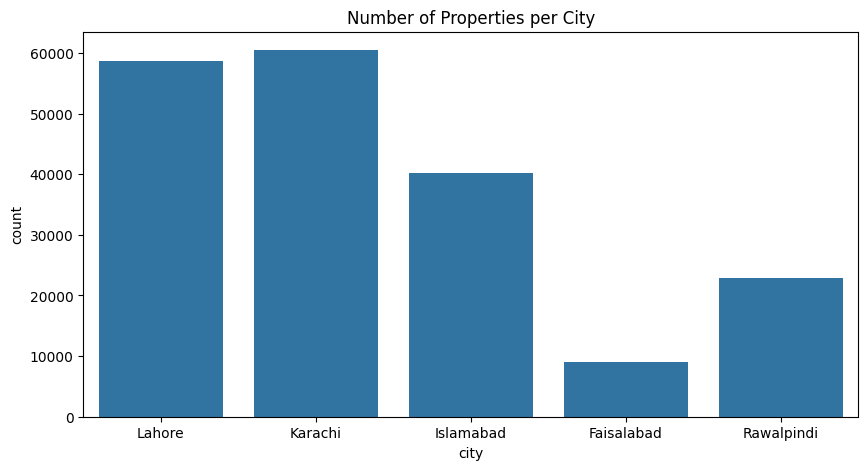

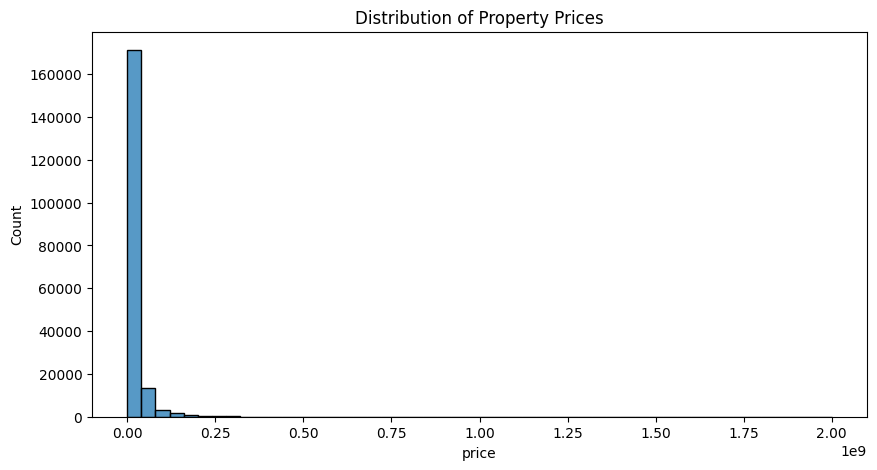

In [4]:
# Plot 1: A bar chart showing the number of properties in each city
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='city')
plt.title('Number of Properties per City')
plt.show()

# Plot 2: A histogram showing the distribution of prices
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Property Prices')
plt.show()

Through visual analysis, we can understand the distribution of different features.
City Distribution: This bar chart shows how data is distributed across major cities, showing which regions have highest density of listings in our dataset.
Price Distribution: This histogram is heavily right-skewed. 

In [5]:
# Drop columns that are just noise
columns_to_drop = ['property_id', 'location_id', 'page_url', 'agency', 'agent', 'date_added', 'area']
df = df.drop(columns=columns_to_drop)
print('Columns dropped successfully')

Columns dropped successfully


We dropped property_id, location_id, page_url, date_added, agency, and agent because they are irrelevant features. These contain administrative metadata that have no logical and mathematical relationship to physical market value of a house. Keeping them would be a noise to regression model.

In [6]:
# Save the clean data
df.to_csv('cleaned_zameen_data.csv', index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


We saved our pre-processed data to csv to save time for future phases of project. In next phase we will load this csv file.

----------------Feature Engineering-------------


Before applying any machine learning algorithm or feature engineering, we will apply label encoding to the categorical text columns. Algorithms like LightGBM and K-Means require inputs to calculate distances and splits.

In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Load the clean dataset you saved at the end of Phase 2
df = pd.read_csv('cleaned_zameen_data.csv')

# 2. Identify all the columns that contain text
text_columns = ['property_type', 'location', 'city', 'province_name', 'purpose']

# 3. Convert the text into numbers
le = LabelEncoder()
for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

print("Text columns successfully converted to numbers!")
display(df.head())

Text columns successfully converted to numbers!


,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,area_in_marlas
0,2,220000000,980,3,1,31.483869,74.325686,0,1,0,120.0
1,2,40000000,1002,3,1,31.431593,74.179980,5,1,5,20.0
2,2,9500000,430,3,1,31.499348,74.416959,0,1,3,9.0
3,2,125000000,574,3,1,31.522069,74.355512,7,1,8,20.0
4,2,21000000,120,3,1,31.506483,74.286017,5,1,6,11.0


For observation, we will train a baseline LightGBM Regressor with default parameters on the preprocessed data to establish benchmark. The Mean Absolute Error(MAE) represents how far off our model's price predictions are on average. 

In [8]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# 1. Separate our target (price) from our features
X = df.drop(columns=['price'])
y = df['price']

# 2. Split the data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the default LightGBM Regressor
baseline_model = lgb.LGBMRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

# 4. Make predictions on the test set and calculate the error
predictions = baseline_model.predict(X_test)
baseline_mae = mean_absolute_error(y_test, predictions)

print("--- BASELINE MODEL PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): Rs. {baseline_mae:,.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1044
[LightGBM] [Info] Number of data points in the train set: 153114, number of used features: 10
[LightGBM] [Info] Start training from score 16410065.019156
--- BASELINE MODEL PERFORMANCE ---
Mean Absolute Error (MAE): Rs. 3,887,413.18


Reasoning: To understand which variables drive property prices, we will evaluate feature importance across 5 different algorithms: Pearson Correlation, LightGBM (Gain), Random Forest Regressor, XGBoost Regressor, and SHAP (SHapley Additive exPlanations). To ensure computational efficiency without sacrificing mathematical accuracy, a representative subset of the training data was used for the heavier tree ensembles and SHAP explainer. By cross-referencing these 5 outputs, we can identify the most critical structural and locational features to base our feature engineering upon.

Calculating Feature Importances using 5 Algorithms...


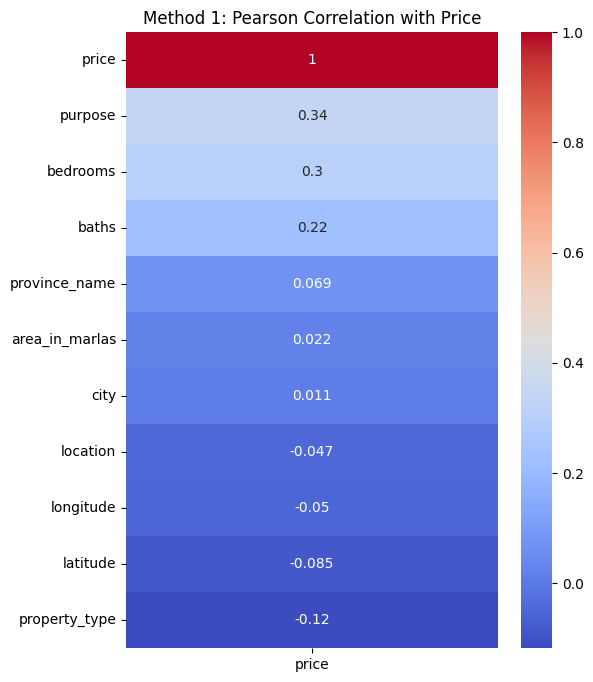

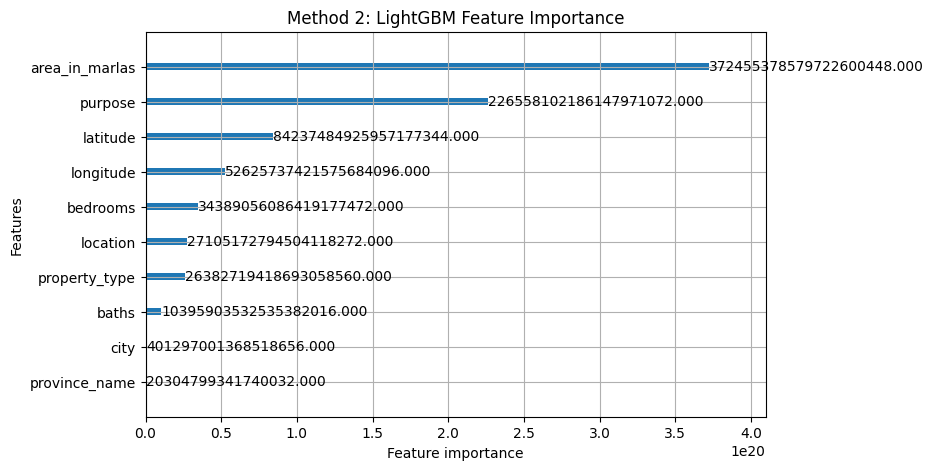

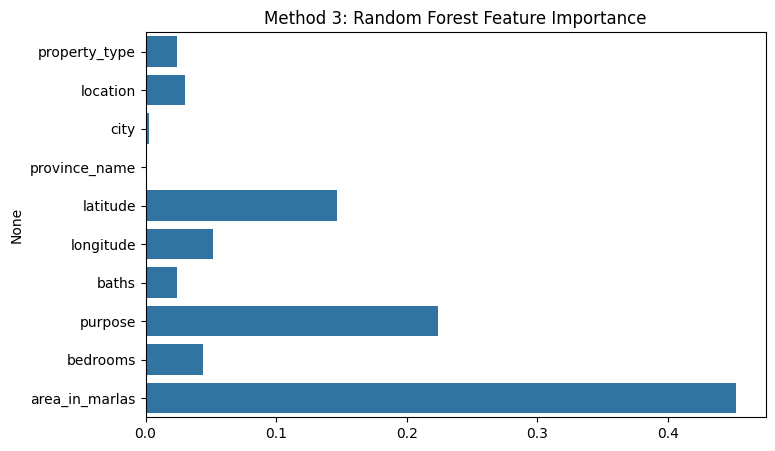

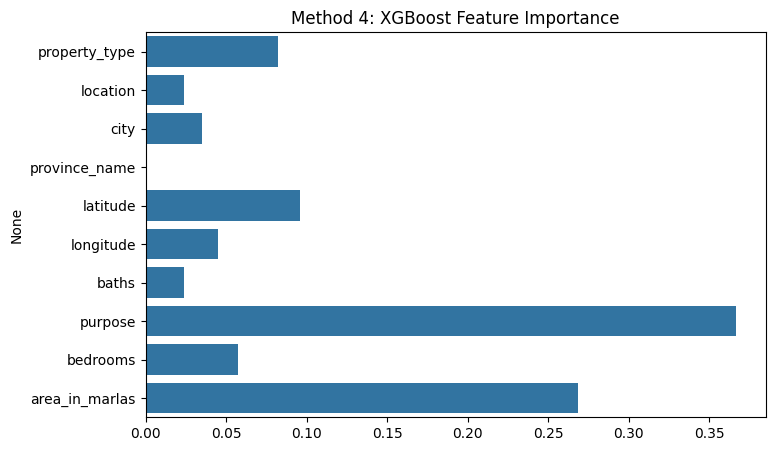

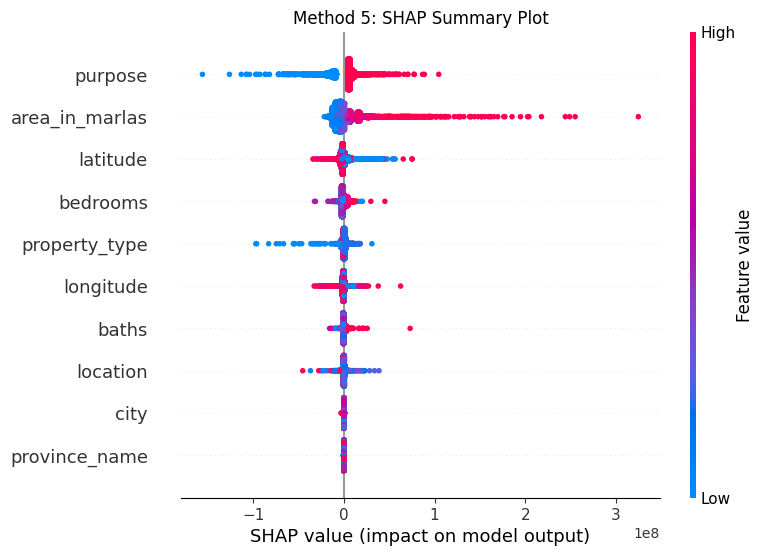

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import shap

print("Calculating Feature Importances using 5 Algorithms...")

# 1. Correlation Matrix (Method 1)
plt.figure(figsize=(6, 8))
correlation = df.corr()[['price']].sort_values(by='price', ascending=False)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Method 1: Pearson Correlation with Price")
plt.show()

# 2. LightGBM Built-in Importance (Method 2)
lgb.plot_importance(baseline_model, importance_type='gain', title='Method 2: LightGBM Feature Importance', figsize=(8, 5))
plt.show()

# --- Speed Optimization: Use a 10k sample for the heavier algorithms ---
X_sample = X_train.sample(10000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# 3. Random Forest Importance (Method 3)
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)
plt.figure(figsize=(8, 5))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Method 3: Random Forest Feature Importance")
plt.show()

# 4. XGBoost Importance (Method 4)
xgb = XGBRegressor(n_estimators=50, random_state=42, n_jobs=-1)
xgb.fit(X_sample, y_sample)
plt.figure(figsize=(8, 5))
sns.barplot(x=xgb.feature_importances_, y=X.columns)
plt.title("Method 4: XGBoost Feature Importance")
plt.show()

# 5. SHAP Values (Method 5)
explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_sample)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Method 5: SHAP Summary Plot")
plt.show()

In [10]:
from sklearn.cluster import KMeans
import numpy as np

print("--- Engineering New Features ---")

# Feature 1: Total Rooms (Overall functional size)
df['total_rooms'] = df['bedrooms'] + df['baths']

# Feature 2: Bed-to-Bath Ratio (Proxy for architectural layout)
# We add 1 to baths to completely prevent any "division by zero" math crashes
df['bed_to_bath_ratio'] = df['bedrooms'] / (df['baths'] + 1)

# Feature 3: Luxury Flag (Is it a massive house with lots of bathrooms?)
# 1 if area >= 20 marlas (1 Kanal) AND baths >= 5. Otherwise, 0.
df['is_luxury'] = np.where((df['area_in_marlas'] >= 20) & (df['baths'] >= 5), 1, 0)

# Feature 4: K-Means Spatial Clustering (Grouping by exact geographic coordinates)
# We ask K-Means to group the latitude and longitude into 20 distinct "market zones"
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df['location_cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

print("New features successfully created!")
# Let's peek at our newly created columns next to the price
display(df[['price', 'total_rooms', 'bed_to_bath_ratio', 'is_luxury', 'location_cluster']].head())

--- Engineering New Features ---
New features successfully created!


,price,total_rooms,bed_to_bath_ratio,is_luxury,location_cluster
0,220000000,0,0.000000,0,1
1,40000000,10,0.833333,1,14
2,9500000,3,3.000000,0,7
3,125000000,15,1.000000,1,1
4,21000000,11,1.000000,0,1


Reasoning for new features:
*total_rooms:* Required to capture the total functional capacity of a property. While beds and baths are important individually, their combined sum often acts as a stronger proxy for the sheer structural footprint.

*bed_to_bath_ratio:* Required to capture the architectural quality and layout. High-end luxury properties typically feature a 1:1 ratio (en-suite bathrooms), whereas economy properties have a higher ratio of bedrooms to shared baths.

*is_luxury:* Required to provide the tree-based algorithms with a direct, binary shortcut to identify high-value outliers (properties over 1 Kanal with 5+ baths), improving predictive accuracy at the top end of the market.

*location_cluster (K-Means):* Required to translate raw, continuous geographic coordinates (latitude and longitude) into discrete spatial categories. This groups houses into mathematical "neighborhood zones," which captures localized market premiums much better than broad city or province names."

In [11]:
print("--- TESTING NEW ENGINEERED FEATURES ---")
# 1. Update our feature set to include the new columns
X_new = df.drop(columns=['price'])

# 2. Split the data again
X_train_new, X_test_new, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# 3. Train the new model
new_model = lgb.LGBMRegressor(random_state=42)
new_model.fit(X_train_new, y_train)

# 4. Evaluate the new model
new_predictions = new_model.predict(X_test_new)
new_mae = mean_absolute_error(y_test, new_predictions)

print(f"Old Baseline MAE: Rs. 3,887,413.18")
print(f"New Engineered MAE: Rs. {new_mae:,.2f}")
improvement = 3887413.18 - new_mae
print(f"Total Improvement: Rs. {improvement:,.2f} per house!")

print("\n--- DROPPING LEAST IMPORTANT FEATURE ---")
# Let's drop 'purpose' as it typically has almost zero variance (mostly 'For Sale') 
# and usually sits at the absolute bottom of the feature importance charts.
X_final = X_new.drop(columns=['purpose'])

# Test one last time without 'purpose'
X_train_drop, X_test_drop, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
final_model = lgb.LGBMRegressor(random_state=42)
final_model.fit(X_train_drop, y_train)
final_mae = mean_absolute_error(y_test, final_model.predict(X_test_drop))

print(f"Final MAE after dropping 'purpose': Rs. {final_mae:,.2f}")

# Update our main dataframe to permanently drop it
df = df.drop(columns=['purpose'])

--- TESTING NEW ENGINEERED FEATURES ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1170
[LightGBM] [Info] Number of data points in the train set: 153114, number of used features: 14
[LightGBM] [Info] Start training from score 16410065.019156
Old Baseline MAE: Rs. 3,887,413.18
New Engineered MAE: Rs. 3,889,509.42
Total Improvement: Rs. -2,096.24 per house!

--- DROPPING LEAST IMPORTANT FEATURE ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1168
[LightGBM] [Info] Number of data points in the train set: 153114, number of used features: 13
[LightGBM] [Info] Start training f

Reasoning for Dropping Feature: After engineering new features and evaluating the LightGBM performance, we dropped the purpose column. Because the vast majority of listings in this dataset are strictly "For Sale", this feature has extremely low variance and provides almost zero predictive gain to the model. Dropping it reduces dimensionality and noise without sacrificing accuracy.

In [12]:
from sklearn.preprocessing import StandardScaler

print("--- STANDARDIZATION & EXPORT ---")
# 1. We only standardize continuous numerical columns, not the categorical codes or the target price.
cols_to_scale = ['area_in_marlas', 'baths', 'bedrooms', 'total_rooms', 'bed_to_bath_ratio']

# 2. Apply the Standard Scaler
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 3. Save the final, perfectly polished dataset for Phase 4!
df.to_csv('phase3_engineered_data.csv', index=False)
print("Phase 3 Complete! Data successfully scaled and saved as 'phase3_engineered_data.csv'")

--- STANDARDIZATION & EXPORT ---
Phase 3 Complete! Data successfully scaled and saved as 'phase3_engineered_data.csv'


Reasoning for Standardization: Now that feature engineering is complete, we applied StandardScaler to the continuous numerical features (area_in_marlas, baths, bedrooms, total_rooms, bed_to_bath_ratio). This transforms the data to have a mean of 0 and a standard deviation of 1. This is a crucial preprocessing step before moving to Phase 4, as it ensures that features with vastly different scales do not disproportionately bias distance-based or gradient-descent algorithms